In [1]:
import pandas as pd
import matplotlib.pyplot as plt
data = pd.read_csv("SuperStoreOrders.csv", encoding='latin1', engine='python',sep=',')
data.head(10)

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,Month,Day
0,AG-2011-2040,01/01/2011,06/01/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,"Tenex Lockers, Blue",408,2,0.0,106.14,35.46,Medium,2011,Jan,Sat
1,IN-2011-47883,01/01/2011,08/01/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,"Acme Trimmer, High Speed",120,3,0.1,36.04,9.72,Medium,2011,Jan,Sat
2,HU-2011-1220,01/01/2011,05/01/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,"Tenex Box, Single Width",66,4,0.0,29.64,8.17,High,2011,Jan,Sat
3,IT-2011-3647632,01/01/2011,05/01/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,"Enermax Note Cards, Premium",45,3,0.5,-26.06,4.82,High,2011,Jan,Sat
4,IN-2011-47883,01/01/2011,08/01/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.77,4.70,Medium,2011,Jan,Sat
5,IN-2011-47883,01/01/2011,08/01/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,"Eaton Computer Printout Paper, 8.5 x 11",55,2,0.1,15.34,1.80,Medium,2011,Jan,Sat
6,CA-2011-1510,02/01/2011,06/01/2011,Standard Class,Magdelene Morse,Consumer,Ontario,Canada,Canada,Canada,...,"Okidata Inkjet, Wireless",314,1,0.0,3.12,24.10,Medium,2011,Jan,Sun
7,IN-2011-79397,03/01/2011,03/01/2011,Same Day,Kean Nguyen,Corporate,New South Wales,Australia,APAC,Oceania,...,"Hoover Microwave, White",276,1,0.1,110.41,125.32,Critical,2011,Jan,Mon
8,ID-2011-80230,03/01/2011,09/01/2011,Standard Class,Ken Lonsdale,Consumer,Auckland,New Zealand,APAC,Oceania,...,"Hewlett Wireless Fax, Laser",912,4,0.4,-319.46,107.10,Low,2011,Jan,Mon
9,IZ-2011-4680,03/01/2011,07/01/2011,Standard Class,Lindsay Williams,Corporate,Ninawa,Iraq,EMEA,EMEA,...,"Novimex Swivel Stool, Set of Two",667,4,0.0,253.32,81.26,High,2011,Jan,Mon


In [10]:
total_sales=(data["sales"]).sum() #Total sales
print(total_sales)

12642905


In [2]:
data['profit'] = pd.to_numeric(data['profit'] ,errors='coerce')  # change datatype 

In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  int64  
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51064 non-null 

In [24]:
total_profit= data['profit'].sum() #total Profit
print(total_profit)

1359588.3900000001


In [25]:
total_quantitySales=data['quantity'].sum() #total no of quantity product sales
print(total_quantitySales)

178312


In [26]:
total_orders=data['order_id'].count() #total no of orders
print(total_orders)

51290


In [27]:
total_Customer=data['customer_name'].nunique() # total no. of Customer
print(total_Customer)

795


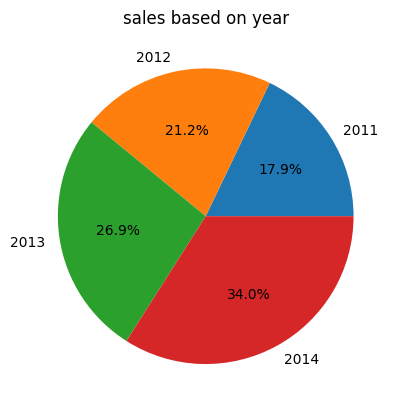

In [3]:
years=data.groupby('year')['sales'].sum() # sales based on year
plt.title("sales based on year")
plt.pie(years,labels =years.index,autopct='%1.1f%%')
plt.show()

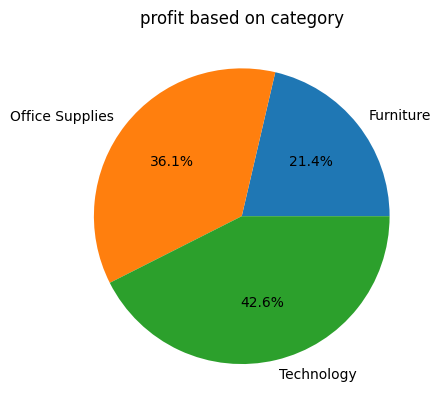

In [46]:
Total_sales=data.groupby('category')['profit'].sum() #  profit based on product category
plt.title("profit based on category")
plt.pie(Total_sales,labels=Total_sales.index,autopct='%1.1f%%')
plt.show()

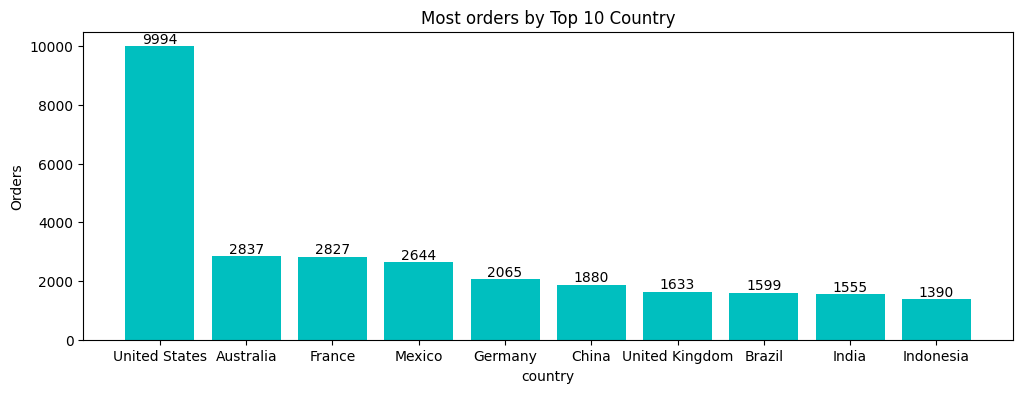

In [61]:
Total_orders=data.groupby('country')['order_id'].count().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,4))
plt.title("Most orders by Top 10 Country")
plt.bar(Total_orders.index, Total_orders.values,color="c")  # Most orders by Top 10 Country
ax=plt.gca()
for i in ax.containers:
    ax.bar_label(i)
plt.ylabel("Orders")
plt.xlabel("country")
plt.show()


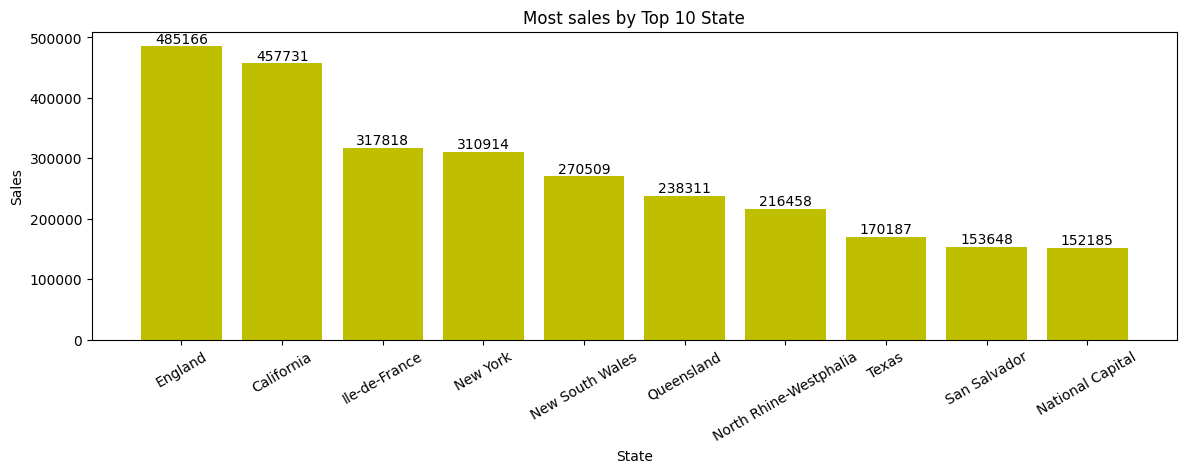

In [69]:
Total_sales=data.groupby('state')['sales'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(14,4))
plt.title("Most sales by Top 10 State")
plt.bar(Total_sales.index, Total_sales.values,color="y")             # top 10 state most sales
ax=plt.gca()                                                           
for i in ax.containers:
    ax.bar_label(i)
plt.ylabel("Sales")
plt.xlabel("State")
plt.xticks(fontsize=10, rotation=30)
plt.show()


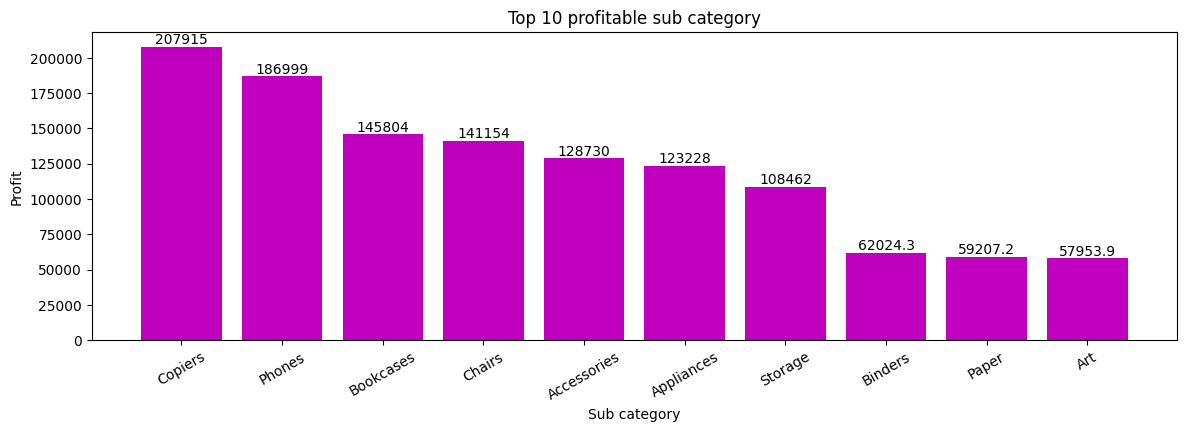

In [71]:
Total_profit=data.groupby('sub_category')['profit'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(14,4))
plt.title("Top 10 profitable sub category")
plt.bar(Total_profit.index, Total_profit.values,color="m")   # Top 10 most profitable by sub category
ax=plt.gca()
for i in ax.containers:
    ax.bar_label(i)
plt.ylabel("Profit")
plt.xlabel("Sub category")
plt.xticks(fontsize=10, rotation=30)
plt.show()

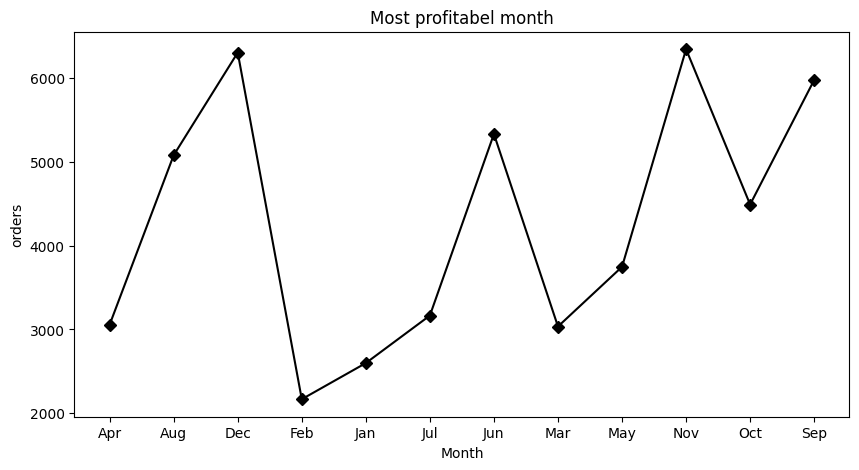

In [92]:
total_orders=data.groupby('Month')['order_id'].count()
plt.figure(figsize=(10,5))
plt.title("Most profitabel month")
plt.plot(total_orders.index,total_orders.values,marker='D',color='k')  #most profitable month 
plt.ylabel("orders")
plt.xlabel("Month")
plt.show()

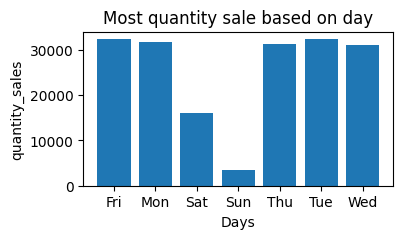

In [95]:
total_quantitysales=data.groupby("Day")['quantity'].sum()
plt.figure(figsize=(4,2))
plt.title("Most quantity sale based on day")                  #most quantity sales based on week days
plt.bar(total_quantitysales.index,total_quantitysales.values)
plt.ylabel("quantity_sales")
plt.xlabel("Days")
plt.show()

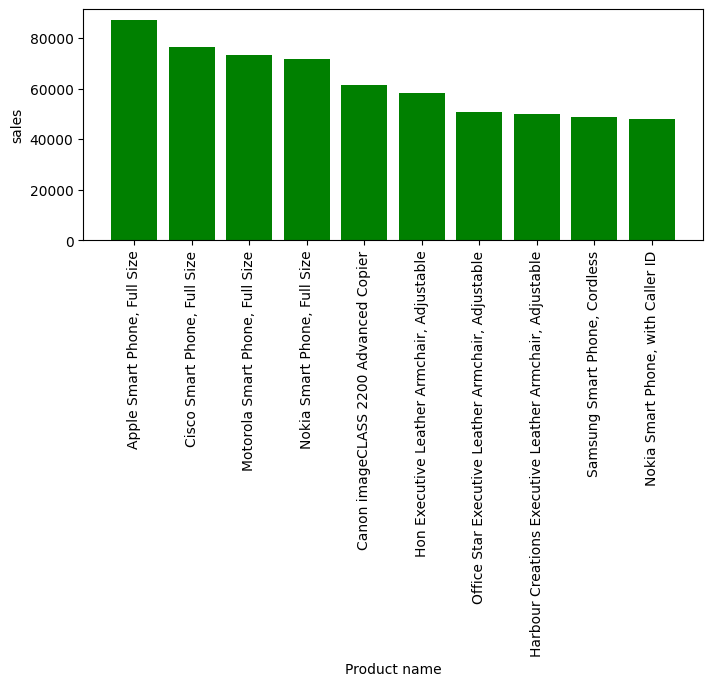

In [107]:
top_product=data.groupby("product_name")['sales'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(8,3))
plt.bar(top_product.index,top_product.values,color="g")  #top 10 product generate most sales
plt.ylabel("sales")
plt.xlabel("Product name")
plt.xticks(fontsize=10, rotation=90)
plt.show()

In [111]:
Total_shiping_cost=data['shipping_cost'].sum()  # total shipping cost 
print(Total_shiping_cost)                       

1352820.69


In [117]:
data['making_cost']= data['sales'] - data['shipping_cost'] - data['profit'] # total making cost
total_making_cost = data['making_cost'].sum()
print(total_making_cost)

9225297.77


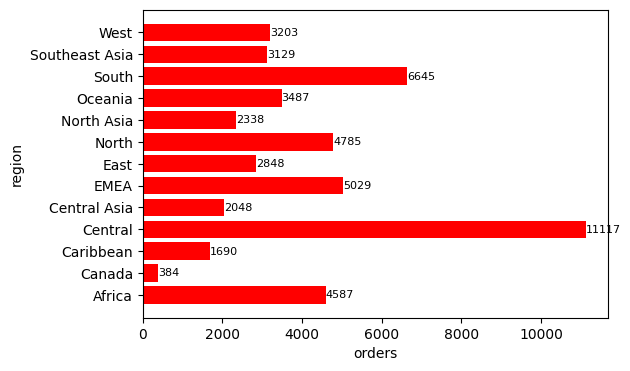

In [43]:
regionwise = data.groupby('region')['order_id'].count()
plt.figure(figsize=(6,4))
plt.barh(regionwise.index,regionwise.values,color="r")
ax=plt.gca()
for i in ax.containers:
    ax.bar_label(i,fontsize=8)
plt.xlabel("orders")
plt.ylabel("region")
plt.yticks(fontsize=10)
plt.show()


In [62]:
profit_margin= (data['profit'].sum() / data['sales'].sum()) *100  #profit margin 
print(profit_margin,"%")

10.753765768231274 %


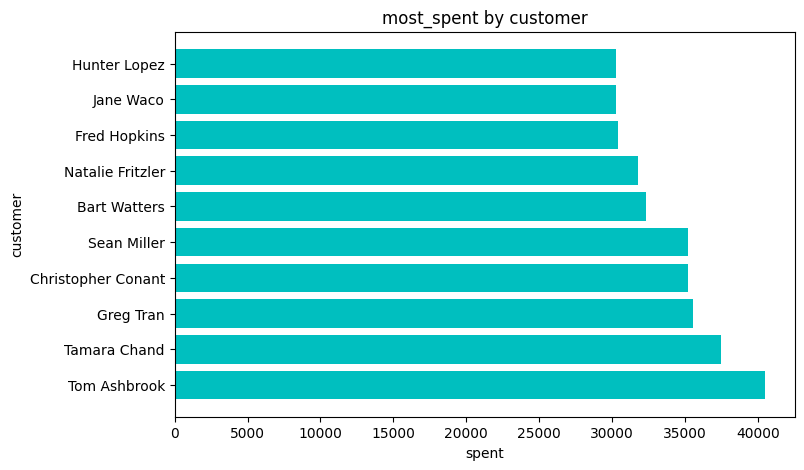

In [72]:
most_spent=data.groupby('customer_name')['sales'].sum().sort_values(ascending=False).head(10)  #top 10 customer most spent 
plt.figure(figsize=(8,5))
plt.barh(most_spent.index,most_spent.values,color="c")
plt.title("most_spent by customer")
plt.xlabel("spent")
plt.ylabel("customer")
plt.show()